[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/MFM/blob/main/notebooks/EN/chapter20_seminar_notebook.ipynb)

# Modelling Financial Markets — Seminar 20 (special chapter): Path Signatures and Realised Volatility

- **Part A**: derivations (signatures, Chen, Lévy area, HAR as AR(22), QLIKE, kernel weights); **Part B**: VOLARE with inference; **Part C**: a level-aware kernel and the critique of an AI answer.
- Solved problems are complete; proposed problems give the task and name their model.

> The solutions are discussed in the seminar.

In [ ]:
# On Colab, install arch first: !pip install arch
# Colab: !pip install arch
import os
import json
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import lars_path
import warnings
warnings.filterwarnings('ignore')

## VOLARE data

- VOLARE (Cipollini, Cruciani, Gallo, Insana, Otranto & Spagnolo, 2026, https://doi.org/10.48550/arXiv.2602.19732) is free for research at http://volare.unime.it.
- Download `realized_variance_stocks.csv`, `realized_variance_futures.csv` and `realized_variance_forex.csv` and set `VOLARE_DIR` to their folder.

In [ ]:
# VOLARE is licensed for research use and is not redistributed with this course.
# Download the three realised-variance files free from http://volare.unime.it
# (realized_variance_stocks.csv, realized_variance_futures.csv, realized_variance_forex.csv)
# and set the folder that contains them (on Colab: upload them or mount Google Drive).
VOLARE_DIR = 'data/volare'
for _d in ('.', '..', '../..', '../../..'):
    if not os.path.isdir(VOLARE_DIR) and os.path.isdir(os.path.join(_d, 'data', 'volare')):
        VOLARE_DIR = os.path.join(_d, 'data', 'volare')
print('VOLARE folder:', os.path.abspath(VOLARE_DIR))

## Signatures, models and tests

- Truncated signatures by Chen's identity, the signature kernel, two-step LASSO with BIC, HAR benchmarks, QLIKE, Diebold-Mariano, Giacomini-White, model confidence set.

In [ ]:
CLASSES = ('stocks', 'futures', 'forex')
COLS = ['date', 'symbol', 'open_price', 'close_price', 'rv5', 'rsp5', 'rsn5', 'rq5', 'rk']
_RAW = {}


def load_class(kind):
    """All realised measures of one VOLARE asset class (stocks, futures, forex)."""
    if kind not in _RAW:
        f = os.path.join(VOLARE_DIR, f'realized_variance_{kind}.csv')
        _RAW[kind] = pd.read_csv(f, usecols=COLS, parse_dates=['date'])
    return _RAW[kind]


def load_asset(kind, symbol):
    """Daily series of one asset: rv (5-minute RV), semivariances, quarticity, kernel, open-to-close return."""
    d = load_class(kind)
    d = d[d.symbol == symbol].sort_values('date').set_index('date')
    out = pd.DataFrame({'rv': d.rv5, 'rsp': d.rsp5, 'rsn': d.rsn5, 'rq': d.rq5, 'rk': d.rk,
                        'r': np.log(d.close_price / d.open_price)})
    out = out[(out.rv > 0) & (out.rsp >= 0) & (out.rsn >= 0) & (out.rq > 0) & np.isfinite(out.r)]
    return out[~out.index.duplicated()]


def symbols(kind):
    return sorted(load_class(kind).symbol.unique())


# -----------------------------------------------------------------------------
# SIGNATURES (numpy, Chen's identity)
# -----------------------------------------------------------------------------
def sig_words(d, depth):
    """Multi-indices (words) of the truncated signature, levels 1..depth, in the order of sig_windows."""
    return [w for k in range(1, depth + 1) for w in itertools.product(range(d), repeat=k)]


def sig_path(path, depth=3):
    """Truncated signature (levels 1..depth) of the piecewise-linear path through the rows of `path` (m x d)."""
    return sig_windows(np.asarray(path, float), len(path), depth)[-1]


def _outer(A, B):
    """Row-wise tensor product of flattened tensors: (m, d^a) x (m, d^b) -> (m, d^(a+b)), lexicographic order."""
    return (A[:, :, None] * B[:, None, :]).reshape(A.shape[0], -1)


def sig_windows(x, l, depth=3):
    """Signatures of all rolling windows of l points of the path x (n x d); row i = window ending at point i.

    Chen's identity: S(X * Y) = S(X) (x) S(Y); a linear segment with increment D has S = exp(D) =
    (1, D, D(x)D/2!, D(x)D(x)D/3!, ...), so level k of the updated signature is
    sum_{p=0..k} S_old^(k-p) (x) D^(x)p / p!.  Rows i < l-1 are NaN."""
    x = np.asarray(x, float)
    n, d = x.shape
    m = n - l + 1
    lev = [np.ones((m, 1))] + [np.zeros((m, d ** k)) for k in range(1, depth + 1)]
    for j in range(l - 1):
        D = x[j + 1:j + 1 + m] - x[j:j + m]                        # increment of segment j in every window
        pw = [np.ones((m, 1))]
        for p in range(1, depth + 1):
            pw.append(_outer(pw[-1], D) / p)                       # D^(x)p / p!
        lev = [lev[0]] + [sum(_outer(lev[k - p], pw[p]) for p in range(0, k + 1)) for k in range(1, depth + 1)]
    flat = np.concatenate(lev[1:], axis=1)
    out = np.full((n, flat.shape[1]), np.nan)
    out[l - 1:] = flat
    return out


def sig_scale(scales, depth=3):
    """Signature of a path whose channel c is multiplied by scales[c]: level-k word (i1..ik) scales by prod."""
    return np.array([np.prod([scales[i] for i in w]) for w in sig_words(len(scales), depth)])


def levy_area(path):
    """Levy area of the first two channels: (S^(1,2) - S^(2,1)) / 2."""
    S = sig_path(path, 2)
    d = np.asarray(path).shape[1]
    s2 = S[d:].reshape(d, d)
    return 0.5 * (s2[0, 1] - s2[1, 0])


def sig_kernel(Sa, Sb):
    """Truncated signature kernel <S^N(a), S^N(b)> including the level-0 term 1."""
    return 1.0 + np.dot(Sa, Sb)


def sig_distance(Sa, Sb):
    """d_Sig(a, b) = k(a,a) - 2 k(a,b) + k(b,b) = ||S^N(a) - S^N(b)||^2."""
    return sig_kernel(Sa, Sa) - 2 * sig_kernel(Sa, Sb) + sig_kernel(Sb, Sb)


# -----------------------------------------------------------------------------
# DESIGN (pre-registered, fixed before any out-of-sample result)
# -----------------------------------------------------------------------------
CFG = dict(
    W=1000,             # rolling estimation window (days of (x_tau, y_tau+h) pairs)
    K=5,                # re-estimation every K trading days (parameters fixed in between)
    L=22,               # signature lookback (points in the path), one trading month
    DEPTH=3,            # truncation depth N
    HORIZONS=(1, 5, 22),
    VAL=250,            # validation block: first 250 forecast days of every asset (only for choosing c)
    C_GRID=(0.5, 1.0, 2.0, 4.0),   # gamma = c / median(d_tau)
    CHANNELS=('t', 'logrv', 'cumret'),
)
MODELS = ['HAR', 'logHAR', 'HARQ', 'SHAR', 'logHAR-K', 'Sig-L', 'Sig-LK']
LABEL = {'HAR': 'HAR', 'logHAR': 'log-HAR', 'HARQ': 'HARQ', 'SHAR': 'SHAR', 'logHAR-K': 'log-HAR + kernel weights',
         'Sig-L': 'Signature LASSO', 'Sig-LK': 'Signature LASSO + kernel weights'}


def har_parts(v):
    """Daily, weekly (5-day) and monthly (22-day) averages of a series ending at each day."""
    s = pd.Series(v)
    return np.c_[s.values, s.rolling(5).mean().values, s.rolling(22).mean().values]


def build_design(a, h, cfg=CFG):
    """Features and targets of one asset for horizon h (arrays aligned on the asset's trading days)."""
    rv = a.rv.values
    n = len(rv)
    lrv = np.log(rv)
    y = pd.Series(rv).rolling(h).mean().shift(-h).values       # mean RV over days t+1..t+h
    H = har_parts(rv)
    D = dict(dates=a.index, rv=rv, y=y, ly=np.log(y), n=n, h=h)
    D['X_har'] = H
    D['X_loghar'] = np.log(H)
    D['sqrq'] = np.sqrt(a.rq.values)
    D['X_shar'] = np.c_[a.rsp.values, a.rsn.values, H[:, 1], H[:, 2]]
    # path for the signature: (time, log RV, cumulative open-to-close return), channels as in cfg
    chan = {'t': np.arange(n, dtype=float) / (cfg['L'] - 1), 'logrv': lrv, 'cumret': np.cumsum(a.r.values),
            'rsn': np.log(np.maximum(a.rsn.values, 1e-12))}
    P = np.column_stack([chan[c] for c in cfg['CHANNELS']])
    D['path'] = P
    D['sig'] = sig_windows(P, cfg['L'], cfg['DEPTH'])
    D['incr'] = np.r_[np.full((1, P.shape[1]), np.nan), np.diff(P, axis=0)]
    return D


# -----------------------------------------------------------------------------
# ESTIMATION
# -----------------------------------------------------------------------------
def wls(X, y, w):
    """Weighted least squares with intercept; returns coefficients (b0, b) and weighted residual variance."""
    Z = np.c_[np.ones(len(y)), X]
    sw = np.sqrt(w)
    b, *_ = np.linalg.lstsq(Z * sw[:, None], y * sw, rcond=None)
    e = y - Z @ b
    return b, float(np.sum(w * e ** 2) / np.sum(w))


def two_step_lasso(X, y, w, max_steps=60):
    """Weighted LASSO path (LARS) -> OLS refit on each support -> BIC with Kish effective sample size.

    Step 1 (Gu et al., 2024, Eq. 14): min_theta sum_tau w_tau (y - x theta)^2 + lambda ||theta||_1.
    Step 2 (Eq. 15): weighted OLS on supp(theta_LASSO).  lambda chosen by BIC inside the window."""
    w = w / w.sum()
    n_eff = 1.0 / np.sum(w ** 2)
    mx = w @ X
    my = w @ y
    sd = np.sqrt(w @ (X - mx) ** 2)
    keep = sd > 1e-12
    Xs = (X[:, keep] - mx[keep]) / sd[keep]
    sw = np.sqrt(w)
    _, _, coefs = lars_path(Xs * sw[:, None], (y - my) * sw, method='lasso', max_iter=max_steps)
    idx = np.where(keep)[0]
    best, seen = None, set()
    for j in range(coefs.shape[1]):
        S = tuple(idx[np.abs(coefs[:, j]) > 0])
        if S in seen:
            continue
        seen.add(S)
        b, s2 = wls(X[:, list(S)], y, w) if S else (np.array([my]), float(w @ (y - my) ** 2))
        bic = n_eff * np.log(s2) + (len(S) + 1) * np.log(n_eff)
        if best is None or bic < best[0]:
            best = (bic, S, b, s2)
    _, S, b, s2 = best
    beta = np.zeros(X.shape[1])
    beta[list(S)] = b[1:]
    return b[0], beta, s2, S


def kernel_weights(sig_train, sig_now, scale, c):
    """w_tau proportional to exp(-gamma d_Sig(window tau, current window)), gamma = c / median(d)."""
    diff = (sig_train - sig_now) * scale
    d = np.sum(diff ** 2, axis=1)
    g = c / np.median(d)
    z = -g * d
    w = np.exp(z - z.max())
    return w / w.sum(), d


def insanity(fc, models):
    """Bollerslev, Patton & Quaedvlieg (2016) filter: a forecast outside the range of the target in the estimation
    window is replaced by the window mean (columns lo, hi, mu of a forecast table)."""
    out = fc.copy()
    for m in models:
        bad = (fc[m] < fc.lo) | (fc[m] > fc.hi)
        out.loc[bad, m] = fc.mu[bad]
    return out


def fit_models(D, t, cfg, c_sig, c_har, models=MODELS, keep_weights=False):
    """Estimate every model at origin t (information up to day t); return a dict of forecast functions."""
    h, W, L = D['h'], cfg['W'], cfg['L']
    tr = np.arange(t - h - W + 1, t - h + 1)                     # tau with tau + h <= t
    y, ly = D['y'][tr], D['ly'][tr]
    uni = np.full(len(tr), 1.0 / len(tr))
    out, info = {}, {}
    if 'HAR' in models:
        b, _ = wls(D['X_har'][tr], y, uni)
        out['HAR'] = ('lvl', b, None, 0.0)
    if 'logHAR' in models:
        b, s2 = wls(D['X_loghar'][tr], ly, uni)
        out['logHAR'] = ('log', b, None, s2)
    if 'HARQ' in models:
        mq = D['sqrq'][tr].mean()
        X = np.c_[D['X_har'][tr, 0], D['X_har'][tr, 0] * (D['sqrq'][tr] - mq), D['X_har'][tr, 1:]]
        b, _ = wls(X, y, uni)
        out['HARQ'] = ('harq', b, mq, 0.0)
    if 'SHAR' in models:
        b, _ = wls(D['X_shar'][tr], y, uni)
        out['SHAR'] = ('shar', b, None, 0.0)
    need_sig = any(m in models for m in ('Sig-L', 'Sig-LK', 'logHAR-K'))
    if need_sig:
        # channel scales from the training window: each non-time channel / (sd of daily increments * sqrt(L-1))
        inc = D['incr'][tr[0]:t + 1]
        sc = []
        for j, cname in enumerate(cfg['CHANNELS']):
            sc.append(1.0 if cname == 't' else 1.0 / (np.nanstd(inc[:, j]) * np.sqrt(L - 1)))
        scale = sig_scale(np.array(sc), cfg['DEPTH'])
        Str = D['sig'][tr]
        Xsig = np.c_[D['X_loghar'][tr], Str * scale]
        if 'Sig-L' in models:
            b0, beta, s2, sup = two_step_lasso(Xsig, ly, uni)
            out['Sig-L'] = ('sig', np.r_[b0, beta], scale, s2)
            info['k_Sig-L'] = len(sup)
            info['S_Sig-L'] = ' '.join(map(str, sup))
        wk, dist = kernel_weights(Str, D['sig'][t], scale, c_sig)
        if 'Sig-LK' in models:
            b0, beta, s2, sup = two_step_lasso(Xsig, ly, wk)
            out['Sig-LK'] = ('sig', np.r_[b0, beta], scale, s2)
            info['k_Sig-LK'] = len(sup)
            info['S_Sig-LK'] = ' '.join(map(str, sup))
            info['ess'] = 1.0 / np.sum(wk ** 2)
            top = D['rv'][tr] >= np.quantile(D['rv'][tr], 0.9)
            info['hv_share'] = float(wk[top].sum())             # weight on the 10% most volatile training days
            info['date'] = D['dates'][t]
            if keep_weights:
                info['weights'] = pd.Series(wk, index=D['dates'][tr])
        if 'logHAR-K' in models:
            wh = wk if c_har == c_sig else kernel_weights(Str, D['sig'][t], scale, c_har)[0]
            b, s2 = wls(D['X_loghar'][tr], ly, wh)
            out['logHAR-K'] = ('log', b, None, s2)
    return out, info, (y.min(), y.max(), y.mean())


def predict(D, s, spec):
    kind, b, extra, s2 = spec
    if kind == 'lvl':
        return b[0] + D['X_har'][s] @ b[1:]
    if kind == 'shar':
        return b[0] + D['X_shar'][s] @ b[1:]
    if kind == 'harq':
        Xh = D['X_har'][s]
        X = np.c_[Xh[:, 0], Xh[:, 0] * (D['sqrq'][s] - extra), Xh[:, 1:]]
        return b[0] + X @ b[1:]
    if kind == 'log':
        return np.exp(b[0] + D['X_loghar'][s] @ b[1:] + 0.5 * s2)
    if kind == 'sig':
        X = np.c_[D['X_loghar'][s], D['sig'][s] * extra]
        return np.exp(b[0] + X @ b[1:] + 0.5 * s2)
    raise ValueError(kind)


def first_origin(D, cfg):
    """First forecast origin: HAR needs 22 days, the signature L points, the training window W pairs."""
    return max(22, cfg['L']) + cfg['W'] + D['h']


def run_forecasts(D, cfg, c_sig, c_har, start, stop, models=MODELS, weight_dates=()):
    """Rolling forecasts for origins start..stop-1; re-estimation every cfg['K'] days."""
    rows, ks, wsave = [], [], {}
    wd = set(pd.DatetimeIndex(weight_dates))
    t = start
    while t < stop:
        blk = np.arange(t, min(t + cfg['K'], stop))
        keepw = any(D['dates'][s] in wd for s in blk)
        specs, info, (lo, hi, mu) = fit_models(D, t, cfg, c_sig, c_har, models, keep_weights=keepw)
        if keepw:
            for s in blk:
                if D['dates'][s] in wd:
                    wsave[D['dates'][s]] = info.get('weights')
        f = {m: predict(D, blk, specs[m]) for m in models}
        for m in models:                                          # positivity: QLIKE needs f > 0
            v = f[m]
            f[m] = np.where((v <= 0) | ~np.isfinite(v), mu, v)
        for i, s in enumerate(blk):
            rows.append([D['dates'][s], D['y'][s], lo, hi, mu] + [f[m][i] for m in models])
        ks.append({k: v for k, v in info.items() if k != 'weights'})
        t += cfg['K']
    fc = pd.DataFrame(rows, columns=['date', 'y', 'lo', 'hi', 'mu'] + list(models)).set_index('date')
    return fc, pd.DataFrame(ks), wsave


# -----------------------------------------------------------------------------
# EVALUATION
# -----------------------------------------------------------------------------
def qlike(y, f):
    """QLIKE(y, f) = y/f - log(y/f) - 1 (Patton, 2011): y is the realised proxy, f the forecast."""
    r = y / f
    return r - np.log(r) - 1.0


def mse(y, f):
    return (y - f) ** 2


def nw_var(d, lag):
    """Newey-West (Bartlett) long-run variance of a series."""
    d = np.asarray(d, float) - np.mean(d)
    T = len(d)
    v = d @ d / T
    for j in range(1, lag + 1):
        v += 2 * (1 - j / (lag + 1)) * (d[j:] @ d[:-j]) / T
    return v


def nw_lag(T, h):
    return int(max(h, np.ceil(T ** (1 / 3))))


def dm_test(la, lb, h):
    """Diebold-Mariano: d = L_A - L_B; t = mean(d) / sqrt(NW var / T); one-sided p for 'A beats B' (d < 0)."""
    d = np.asarray(la) - np.asarray(lb)
    T = len(d)
    t = d.mean() / np.sqrt(nw_var(d, nw_lag(T, h)) / T)
    return t, stats.norm.cdf(t), 2 * stats.norm.sf(abs(t))


def gw_test(la, lb, h):
    """Giacomini-White conditional test, instruments (1, d_{t-h}); Wald ~ chi2(2)."""
    d = np.asarray(la) - np.asarray(lb)
    Z = np.c_[np.ones(len(d) - h), d[:-h]] * d[h:, None]
    T = len(Z)
    zb = Z.mean(0)
    Zc = Z - zb
    lag = nw_lag(T, h)
    O = Zc.T @ Zc / T
    for j in range(1, lag + 1):
        G = Zc[j:].T @ Zc[:-j] / T
        O += (1 - j / (lag + 1)) * (G + G.T)
    stat = T * zb @ np.linalg.solve(O, zb)
    return stat, stats.chi2.sf(stat, 2)


def holm(p):
    p = np.asarray(p)
    o = np.argsort(p)
    m = len(p)
    adj = np.maximum.accumulate((m - np.arange(m)) * p[o])
    out = np.empty(m)
    out[o] = np.minimum(adj, 1)
    return out


def bh(p):
    p = np.asarray(p)
    o = np.argsort(p)
    m = len(p)
    adj = np.minimum.accumulate((m / np.arange(m, 0, -1)) * p[o][::-1])[::-1]
    out = np.empty(m)
    out[o] = np.minimum(adj, 1)
    return out


def mcs(losses, size=0.10, reps=1000, block=None, seed=20):
    """Model confidence set (Hansen, Lunde & Nason, 2011), T_max statistic, stationary bootstrap."""
    from arch.bootstrap import MCS
    L = pd.DataFrame(losses)
    m = MCS(L, size=size, reps=reps, block_size=block or 10, method='max', bootstrap='stationary', seed=seed)
    m.compute()
    return list(m.included), m.pvalues['Pvalue'].to_dict()

## Chart style

In [ ]:
# Stil standard MFM (identic cu SFM): transparent + ENG + legenda jos
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['savefig.facecolor'] = 'none'
plt.rcParams['savefig.transparent'] = True
plt.rcParams['axes.grid'] = False
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 9
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.linewidth'] = 0.6
plt.rcParams['lines.linewidth'] = 1.1
plt.rcParams['legend.facecolor'] = 'none'
plt.rcParams['legend.framealpha'] = 0
plt.rcParams['legend.fontsize'] = 8

# Culori brand
MainBlue = '#1A3A6E'
IDAred   = '#CD0000'
Forest   = '#2E7D32'
Amber    = '#B5853F'
Orange   = '#E67E22'
Purple   = '#8E44AD'
Gray     = '#7F7F7F'   # doar linii de referinta, benzi, grila
Teal     = '#17A2B8'
COL = {'HAR': MainBlue, 'logHAR': Teal, 'HARQ': Purple, 'SHAR': Amber, 'logHAR-K': Orange,
       'Sig-L': Forest, 'Sig-LK': IDAred}
SHORT = {'HAR': 'HAR', 'logHAR': 'log-HAR', 'HARQ': 'HARQ', 'SHAR': 'SHAR', 'logHAR-K': 'log-HAR-K',
         'Sig-L': 'Sig-L', 'Sig-LK': 'Sig-LK'}
CLASS_LABEL = {'stocks': 'US stocks (40)', 'futures': 'Futures (5)', 'forex': 'FX (5)', 'all': 'All 50 assets'}
PERIODS = {'covid': ('2020-02-20', '2020-04-30'), 'apr2025': ('2025-04-02', '2025-04-30')}
H = CFG['HORIZONS']


def save_fig(name):
    """Show the figure (the Quantlet folder contains the saved PDF/PNG)."""
    plt.show()
    plt.close()


def legend_outside_bottom(ax, ncol=2, y=-0.22):
    """Plaseaza legenda in afara graficului, jos-centru."""
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def fig_legend_bottom(fig, axes, ncol=4, y=0.0):
    """O singura legenda sub o figura cu mai multe panouri."""
    h, l = [], []
    for ax in axes:
        for hh, ll in zip(*ax.get_legend_handles_labels()):
            if ll not in l:
                h.append(hh)
                l.append(ll)
    fig.legend(h, l, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)

## Seminar functions

In [ ]:
RES = {}


def lecture_results():
    """Published results of the lecture case study (ch20_results.json in this folder or on GitHub)."""
    for d in ('.', '../MFM_ch20_case_study', '../../Quantlets/Ch_20', '../Quantlets/Ch_20'):
        f = os.path.join(d, 'ch20_results.json')
        if os.path.exists(f):
            return json.load(open(f))
    import urllib.request
    url = 'https://raw.githubusercontent.com/danpele/MFM/main/Quantlets/Ch_20/MFM_ch20_case_study/ch20_results.json'
    return json.load(urllib.request.urlopen(url))


def ols_hac(y, X, lag):
    """OLS with Newey-West standard errors; X without constant."""
    Z = np.c_[np.ones(len(y)), X]
    b = np.linalg.lstsq(Z, y, rcond=None)[0]
    e = y - Z @ b
    T = len(y)
    Zi = np.linalg.inv(Z.T @ Z)
    G = (Z * e[:, None])
    Sg = G.T @ G / T
    for j in range(1, lag + 1):
        C = G[j:].T @ G[:-j] / T
        Sg += (1 - j / (lag + 1)) * (C + C.T)
    V = T * Zi @ Sg @ Zi
    return b, np.sqrt(np.diag(V)), V


# -----------------------------------------------------------------------------
# PARTEA A
# -----------------------------------------------------------------------------
def part_a():
    A = {}
    # A1: time-augmented path of a series y = (0, 2, 3, 3) at t = (0, 1, 2, 3)
    P = np.array([[0, 0], [1, 2], [2, 3], [3, 3]], float)
    s = sig_path(P, 2)
    A['a1'] = {'lvl1': s[:2].tolist(), 'lvl2': s[2:].reshape(2, 2).tolist(), 'levy': levy_area(P)}
    # A2: path (0,0) -> (2,1) -> (3,-1) -> (4,2) in R^2 (proposed)
    P2 = np.array([[0, 0], [2, 1], [3, -1], [4, 2]], float)
    s2 = sig_path(P2, 2)
    A['a2'] = {'lvl1': s2[:2].tolist(), 'lvl2': s2[2:].reshape(2, 2).tolist(), 'levy': levy_area(P2)}
    # A3/A4: unit square loop and its translate
    sq = np.array([[0, 0], [1, 0], [1, 1], [0, 1], [0, 0]], float)
    A['a4'] = {'levy_square': levy_area(sq), 'levy_square_shift': levy_area(sq + 5),
               'levy_square_cw': levy_area(sq[::-1])}
    # A5: HAR as a restricted AR(22) with the full-sample log-HAR of JPM
    a = load_asset('stocks', 'JPM')
    D = build_design(a, 1)
    ok = np.isfinite(D['X_loghar']).all(1) & np.isfinite(D['ly'])
    b, se, _ = ols_hac(D['ly'][ok], D['X_loghar'][ok], 5)
    phi = np.r_[b[1] + b[2] / 5 + b[3] / 22, np.repeat(b[2] / 5 + b[3] / 22, 4), np.repeat(b[3] / 22, 17)]
    A['a5'] = {'b': b.tolist(), 'se': se.tolist(), 'phi1': phi[0], 'phi2': phi[1], 'phi6': phi[5], 'sum': phi.sum(),
               'N': int(ok.sum())}
    # A7: QLIKE of +/-50% errors
    A['a7'] = {'under': float(qlike(1.0, 0.5)), 'over': float(qlike(1.0, 1.5)),
               'mse_under': 0.25, 'mse_over': 0.25}
    # A9: kernel weights for distances (0.2, 0.5, 1.0, 2.0), gamma = 1 and gamma = 3
    d = np.array([0.2, 0.5, 1.0, 2.0])
    for g in (1.0, 3.0):
        w = np.exp(-g * d) / np.exp(-g * d).sum()
        A[f'a9_g{int(g)}'] = {'w': w.tolist(), 'ess': float(1 / np.sum(w ** 2))}
    RES['A'] = A


# -----------------------------------------------------------------------------
# PARTEA B
# -----------------------------------------------------------------------------
def levy_regression(kind, sym):
    """Does the Levy area (return, log RV) of the last 22 days predict the next-month change of log RV?"""
    a = load_asset(kind, sym)
    D = build_design(a, 22)
    P = D['path']                                   # (t, log RV, cumulative return)
    sig = sig_windows(P[:, [2, 1]], 22, 2)        # channels (return, log RV) only: level 2 gives the area
    levy = 0.5 * (sig[:, 3] - sig[:, 4])
    y = D['ly'] - D['X_loghar'][:, 2]               # log of next-month RV minus log of past-month mean RV
    X = np.c_[D['X_loghar'], levy / np.nanstd(levy)]
    ok = np.isfinite(X).all(1) & np.isfinite(y)
    b, se, _ = ols_hac(y[ok], X[ok], 22)
    b0, se0, _ = ols_hac(y[ok], X[ok][:, :3], 22)
    e1 = y[ok] - np.c_[np.ones(ok.sum()), X[ok]] @ b
    e0 = y[ok] - np.c_[np.ones(ok.sum()), X[ok][:, :3]] @ b0
    r2 = 1 - e1.var() / y[ok].var()
    r20 = 1 - e0.var() / y[ok].var()
    return {'b_levy': b[4], 'se_levy': se[4], 't_levy': b[4] / se[4], 'r2': r2, 'r2_base': r20,
            'N': int(ok.sum()), 'mean_levy': float(np.nanmean(levy)), 'frac_neg': float(np.nanmean(levy < 0))}


def har_family(kind, sym):
    a = load_asset(kind, sym)
    D = build_design(a, 1)
    ok = np.isfinite(D['X_har']).all(1) & np.isfinite(D['y'])
    y = D['y'][ok]
    out = {'N': int(ok.sum())}
    b, se, _ = ols_hac(y, D['X_har'][ok], 5)
    out['har'] = {'b': b.tolist(), 'se': se.tolist()}
    b, se, V = ols_hac(y, D['X_shar'][ok], 5)
    diff = b[2] - b[1]
    sd = np.sqrt(V[2, 2] + V[1, 1] - 2 * V[1, 2])
    out['shar'] = {'b': b.tolist(), 'se': se.tolist(), 'diff': diff, 't_diff': diff / sd,
                   'p_diff': float(stats.norm.sf(diff / sd))}
    sq = D['sqrq'][ok]
    Xq = np.c_[D['X_har'][ok, 0], D['X_har'][ok, 0] * (sq - sq.mean()), D['X_har'][ok, 1:]]
    b, se, _ = ols_hac(y, Xq, 5)
    out['harq'] = {'b': b.tolist(), 'se': se.tolist(), 't_q': b[2] / se[2]}
    return out


def block_boot_ratio(la, lb, block=10, B=2000, seed=20):
    """Stationary-bootstrap CI for mean(la) / mean(lb)."""
    rng = np.random.default_rng(seed)
    T = len(la)
    p = 1.0 / block
    stats_ = []
    for _ in range(B):
        idx = np.empty(T, int)
        idx[0] = rng.integers(T)
        for i in range(1, T):
            idx[i] = rng.integers(T) if rng.random() < p else (idx[i - 1] + 1) % T
        stats_.append(la[idx].mean() / lb[idx].mean())
    return np.percentile(stats_, [2.5, 97.5]).tolist()


def sig_vs_loghar(kind, sym, h, c):
    cfg = dict(CFG)
    a = load_asset(kind, sym)
    D = build_design(a, h, cfg)
    st = first_origin(D, cfg) + cfg['VAL'] + h
    fc, info, _ = run_forecasts(D, cfg, c, c, st, len(a) - h, models=['logHAR', 'Sig-LK'])
    qa, qb = qlike(fc.y.values, fc['Sig-LK'].values), qlike(fc.y.values, fc['logHAR'].values)
    t, p1, p2 = dm_test(qa, qb, h)
    gw, pgw = gw_test(qa, qb, h)
    ci = block_boot_ratio(qa, qb, block=max(h, 10), B=1000)
    return {'T': len(fc), 'start': str(fc.index[0].date()), 'end': str(fc.index[-1].date()),
            'ql_sig': float(qa.mean()), 'ql_har': float(qb.mean()), 'ratio': float(qa.mean() / qb.mean()),
            'ci': ci, 't': float(t), 'p1': float(p1), 'p2': float(p2), 'gw': float(gw), 'p_gw': float(pgw),
            'k': float(info['k_Sig-LK'].mean()), 'ess': float(info['ess'].mean())}, fc


def part_b():
    B = {}
    B['b1'] = levy_regression('stocks', 'JPM')
    B['b2'] = levy_regression('futures', 'ES')
    B['b3'] = har_family('stocks', 'JPM')
    B['b4'] = har_family('futures', 'CL')
    val = lecture_results()['validation']
    B['b5'], fc = sig_vs_loghar('stocks', 'JPM', 1, val['Sig-LK|1']['c'])
    B['b6'], _ = sig_vs_loghar('futures', 'ES', 5, val['Sig-LK|5']['c'])
    # B5 chart: cumulative QLIKE difference
    d = (qlike(fc.y, fc['Sig-LK']) - qlike(fc.y, fc['logHAR'])).cumsum()
    fig, ax = plt.subplots(figsize=(8.5, 3.2))
    ax.plot(d.index, d, color=IDAred, lw=1.0, label='Cumulative QLIKE(Sig-LK) - QLIKE(log-HAR), JPM, h = 1')
    ax.axhline(0, color=Gray, ls='--', lw=0.8)
    ax.set_ylabel('Cumulative loss difference')
    legend_outside_bottom(ax, ncol=1, y=-0.12)
    save_fig('ch20_sem_cumloss')
    # B7/B8: multiple testing on the lecture's 50 DM p-values
    LR = lecture_results()
    for key, h, comp in [('b7', 1, 'Sig-LK|logHAR'), ('b8', 22, 'Sig-LK|HAR')]:
        dmp = LR['dm_p'][str(h)][comp]                      # {kind|sym: one-sided DM p-value}
        rows = [(k.split('|')[1], k.split('|')[0], v) for k, v in dmp.items()]
        p = np.array([r[2] for r in rows])
        o = np.argsort(p)
        fx = sorted([(r[0], r[2]) for r in rows if r[1] == 'forex'], key=lambda x: x[1])
        pf = np.array([pp for _, pp in fx])
        B[key] = {'n': len(p), 'raw': int((p < 0.05).sum()), 'holm': int((holm(p) < 0.05).sum()),
                  'bh': int((bh(p) < 0.05).sum()), 'smallest': [(rows[i][0], float(p[i])) for i in o[:5]],
                  'fx': fx, 'fx_holm': holm(pf).tolist(), 'fx_bh': bh(pf).tolist()}
    RES['B'] = B


# -----------------------------------------------------------------------------
# PARTEA C: nucleu cu punct de baza (vede nivelul volatilitatii)
# -----------------------------------------------------------------------------
def _outer(A, B_):
    return (A[:, :, None] * B_[:, None, :]).reshape(A.shape[0], -1)


def prepend_segment(v, sig, d, depth):
    """Chen: signature of (segment with increment v) * path = exp(v) (x) Sig(path), rows vectorised."""
    m = sig.shape[0]
    lv = [np.ones((m, 1))]
    pos = 0
    for k in range(1, depth + 1):
        lv.append(sig[:, pos:pos + d ** k])
        pos += d ** k
    pw = [np.ones((m, 1))]
    for p in range(1, depth + 1):
        pw.append(_outer(pw[-1], v) / p)
    out = [sum(_outer(pw[p], lv[k - p]) for p in range(0, k + 1)) for k in range(1, depth + 1)]
    return np.concatenate(out, axis=1)


def basepoint_job(kind, sym, h, c):
    """Sig-LK whose kernel distance uses the basepoint-augmented path (level of log RV relative to the window mean)."""
    cfg = dict(CFG)
    a = load_asset(kind, sym)
    D = build_design(a, h, cfg)
    st = first_origin(D, cfg) + cfg['VAL'] + h
    stop = len(a) - h
    L, W = cfg['L'], cfg['W']
    lrv = np.log(a.rv.values)
    rows = []
    t = st
    while t < stop:
        tr = np.arange(t - h - W + 1, t - h + 1)
        inc = D['incr'][tr[0]:t + 1]
        sc = np.array([1.0] + [1.0 / (np.nanstd(inc[:, j]) * np.sqrt(L - 1)) for j in (1, 2)])
        scale = sig_scale(sc, cfg['DEPTH'])
        idx = np.r_[tr, t]
        start = idx - L + 1                                    # first point of each window
        mu, sd = lrv[tr].mean(), lrv[tr].std()
        v = np.c_[np.zeros(len(idx)), (lrv[start] - mu) / sd, np.zeros(len(idx))]
        sbp = prepend_segment(v, D['sig'][idx] * scale, 3, cfg['DEPTH'])
        dist = np.sum((sbp[:-1] - sbp[-1]) ** 2, axis=1)
        g = c / np.median(dist)
        w = np.exp(-g * (dist - dist.min()))
        w /= w.sum()
        Xsig = np.c_[D['X_loghar'][tr], D['sig'][tr] * scale]
        b0, beta, s2, sup = two_step_lasso(Xsig, D['ly'][tr], w)
        blk = np.arange(t, min(t + cfg['K'], stop))
        X = np.c_[D['X_loghar'][blk], D['sig'][blk] * scale]
        f = np.exp(b0 + X @ beta + 0.5 * s2)
        for i, s_ in enumerate(blk):
            rows.append([D['dates'][s_], D['y'][s_], f[i], 1 / np.sum(w ** 2)])
        t += cfg['K']
    fc = pd.DataFrame(rows, columns=['date', 'y', 'Sig-LK-bp', 'ess']).set_index('date')
    main, _, _ = run_forecasts(D, cfg, c, c, st, stop, models=['HAR', 'logHAR', 'Sig-LK'])
    main = main.reindex(fc.index)
    q = {m: qlike(fc.y.values, main[m].values) for m in ['logHAR', 'Sig-LK', 'HAR']}
    q['Sig-LK-bp'] = qlike(fc.y.values, fc['Sig-LK-bp'].values)
    covid = (fc.index >= '2020-02-20') & (fc.index <= '2020-04-30')
    t_, p1, _ = dm_test(q['Sig-LK-bp'], q['logHAR'], h)
    return {'sym': sym, 'ql': {m: float(v.mean()) for m, v in q.items()},
            'ql_covid': {m: float(v[covid].mean()) for m, v in q.items()} if covid.any() else None,
            'p_vs_loghar': float(p1), 'ess': float(fc.ess.mean())}


def part_c(syms=None):
    from joblib import Parallel, delayed
    c = lecture_results()['validation']['Sig-LK|1']['c']
    syms = syms or symbols('stocks')
    out = Parallel(n_jobs=int(os.environ.get('CH20_JOBS', '14')))(delayed(basepoint_job)('stocks', s, 1, c) for s in syms)
    Q = pd.DataFrame({o['sym']: o['ql'] for o in out}).T
    QC = pd.DataFrame({o['sym']: o['ql_covid'] for o in out}).T
    p = np.array([o['p_vs_loghar'] for o in out])
    rel = Q.div(Q['logHAR'], axis=0)
    relc = QC.div(QC['logHAR'], axis=0)
    RES['C'] = {'c': c, 'rel': rel.mean().to_dict(), 'rel_covid': relc.mean().to_dict(),
                'wins_raw': int((p < 0.05).sum()), 'wins_holm': int((holm(p) < 0.05).sum()),
                'wins_bh': int((bh(p) < 0.05).sum()), 'n': len(p), 'ess': float(np.mean([o['ess'] for o in out])),
                'n_better': int((rel['Sig-LK-bp'] < rel['Sig-LK']).sum())}
    RES['C']['per_stock'] = rel[['Sig-LK', 'Sig-LK-bp']].round(4).to_dict('index')
    fig, ax = plt.subplots(figsize=(5.2, 4.2))
    ax.scatter(rel['Sig-LK'], rel['Sig-LK-bp'], color=MainBlue, s=16, label='One stock (h = 1)')
    lo = min(rel['Sig-LK'].min(), rel['Sig-LK-bp'].min()) - 0.01
    hi = max(rel['Sig-LK'].max(), rel['Sig-LK-bp'].max()) + 0.01
    ax.plot([lo, hi], [lo, hi], color=Gray, ls='--', lw=0.8)
    ax.axhline(1, color=Gray, lw=0.5)
    ax.axvline(1, color=Gray, lw=0.5)
    for s_ in rel.index:
        if abs(rel.loc[s_, 'Sig-LK-bp'] - rel.loc[s_, 'Sig-LK']) > 0.04:
            ax.annotate(s_, (rel.loc[s_, 'Sig-LK'], rel.loc[s_, 'Sig-LK-bp']), fontsize=7, color='black',
                        xytext=(3, 3), textcoords='offset points')
    ax.set_xlabel('Sig-LK, plain kernel: QLIKE / log-HAR')
    ax.set_ylabel('Sig-LK, basepoint kernel: QLIKE / log-HAR')
    legend_outside_bottom(ax, ncol=1, y=-0.16)
    save_fig('ch20_sem_basepoint')

## Part A — derivations

### A1. A depth-2 signature, step by step [Solved]

- Series $y = (0, 2, 3, 3)$ on days $0..3$, path $(t, y_t)$.

In [6]:
# Solution
P = np.array([[0, 0], [1, 2], [2, 3], [3, 3]], float)
s = sig_path(P, 2)
print('level 1:', s[:2], '\nlevel 2:\n', s[2:].reshape(2, 2), '\nLevy area:', levy_area(P))

level 1: [3. 3.] 
level 2:
 [[4.5 2.5]
 [6.5 4.5]] 
Levy area: -2.0


### A2. Signature and shuffle identity [Proposed]

- Model: A1. Path $(0,0) \to (2,1) \to (3,-1) \to (4,2)$.

In [ ]:
# Your code here


### A3. Chen's identity and path reversal [Solved]

In [8]:
# Solution
X = np.array([[0, 0], [1, 0], [1, 2]], float)
Xr = X[::-1]
XX = np.vstack([X, Xr[1:]])
print('Sig(X) level 2:\n', sig_path(X, 2)[2:].reshape(2, 2))
print('Sig(reversed) level 2:\n', sig_path(Xr, 2)[2:].reshape(2, 2))
print('there and back, levels 1-2:', sig_path(XX, 2).round(12))

Sig(X) level 2:
 [[0.5 2. ]
 [0.  2. ]]
Sig(reversed) level 2:
 [[0.5 0. ]
 [2.  2. ]]
there and back, levels 1-2: [0. 0. 0. 0. 0. 0.]


### A4. Lévy area of a loop [Proposed]

- Model: A3. The unit square, both directions and translated.

In [ ]:
# Your code here


### A5. HAR as a restricted AR(22) [Solved]

- Full-sample log-HAR for JPM, Newey-West (5 lags).

In [10]:
# Solution
part_a()
pd.Series(RES['A']['a5']).drop(['b', 'se'])

phi1    0.470206
phi2    0.059622
phi6     0.01008
sum     0.880048
N           2764
dtype: object

### A6. Testing the HAR restrictions [Proposed]

- Model: A5. Wald test of the 19 restrictions with a Newey-West covariance.

In [ ]:
# Your code here


### A7. QLIKE: minimiser and asymmetry [Solved]

In [12]:
# Solution
F = np.linspace(0.3, 3, 271)
rv = np.random.default_rng(1).lognormal(0, 0.8, 100000)
EL = [qlike(rv, f).mean() for f in F]
print('argmin of mean QLIKE:', F[np.argmin(EL)].round(2), ' mean RV:', rv.mean().round(2))
print('QLIKE(1, 0.5) =', qlike(1.0, 0.5).round(3), ' QLIKE(1, 1.5) =', qlike(1.0, 1.5).round(3))

argmin of mean QLIKE: 1.37  mean RV: 1.37
QLIKE(1, 0.5) = 0.307  QLIKE(1, 1.5) = 0.072


### A8. QLIKE with its arguments swapped [Proposed]

- Model: A7.

In [ ]:
# Your code here


### A9. Kernel weights and effective sample size [Solved]

In [14]:
# Solution
d = np.array([0.2, 0.5, 1.0, 2.0])
for g in (1, 3):
    w = np.exp(-g * d) / np.exp(-g * d).sum()
    print(f'gamma = {g}: w = {w.round(3)}, n_eff = {1 / np.sum(w ** 2):.2f}')

gamma = 1: w = [0.425 0.315 0.191 0.07 ], n_eff = 3.12
gamma = 3: w = [0.666 0.271 0.06  0.003], n_eff = 1.92


### A10. Limits of the temperature [Proposed]

- Model: A9.

In [ ]:
# Your code here


## Part B — signatures and volatility on VOLARE

### B1. Does the Lévy area predict volatility? (JPM) [Solved]

- Interpretation: why 22 Newey-West lags? Is the $R^2$ gain economically relevant?

In [16]:
# Solution
pd.Series(levy_regression('stocks', 'JPM')).round(4)

b_levy          0.0425
se_levy         0.0360
t_levy          1.1817
r2              0.2856
r2_base         0.2802
N            2743.0000
mean_levy       0.0017
frac_neg        0.4594
dtype: float64

### B2. The Lévy area for E-mini S&P 500 futures [Proposed]

- Model: B1. What does a positive coefficient say about leverage-type windows?

In [ ]:
# Your code here


### B3. HAR, SHAR and HARQ for JPM, with HAC errors [Solved]

- Interpretation: do the good/bad volatility asymmetry and the HARQ effect hold for JPM?

In [18]:
# Solution
r = har_family('stocks', 'JPM')
print({k: np.round(v, 4) for k, v in r['shar'].items()})
print({k: np.round(v, 4) for k, v in r['harq'].items()})

{'b': array([ 0.    ,  0.4014,  0.3235,  0.4962, -0.0248]), 'se': array([0.    , 0.2518, 0.2357, 0.1542, 0.0927]), 'diff': np.float64(-0.0778), 't_diff': np.float64(-0.1672), 'p_diff': np.float64(0.5664)}
{'b': array([  0.    ,   0.7007, -35.0623,   0.3928,  -0.0723]), 'se': array([ 0.    ,  0.1508, 15.9039,  0.1338,  0.091 ]), 't_q': np.float64(-2.2046)}


### B4. HAR, SHAR and HARQ for crude oil [Proposed]

- Model: B3. Why might the asymmetry be stronger for a commodity?

In [ ]:
# Your code here


### B5. Sig-LK vs log-HAR for JPM, one day ahead [Solved]

- Interpretation: is there any evidence that the signature adds value for JPM?

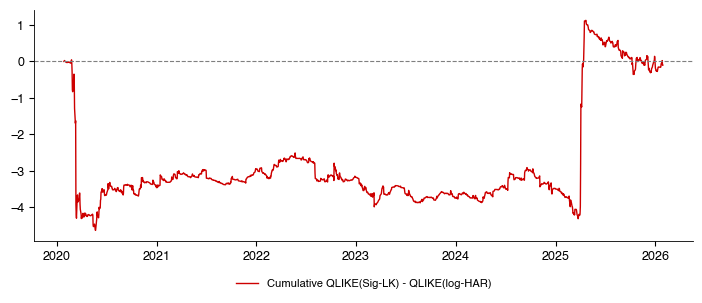

T                                            1511
start                                  2020-01-27
end                                    2026-01-29
ql_sig                                    0.17262
ql_har                                   0.172687
ratio                                    0.999612
ci        [0.956148549523607, 1.0470004444676588]
t                                        -0.01721
p1                                       0.493134
p2                                       0.986269
gw                                       2.845276
p_gw                                     0.241077
k                                        4.211221
ess                                    850.591817
dtype: object

In [20]:
# Solution
c1 = lecture_results()['validation']['Sig-LK|1']['c']
b5, fc5 = sig_vs_loghar('stocks', 'JPM', 1, c1)
d = (qlike(fc5.y, fc5['Sig-LK']) - qlike(fc5.y, fc5['logHAR'])).cumsum()
fig, ax = plt.subplots(figsize=(8.5, 3))
ax.plot(d.index, d, color=IDAred, lw=1, label='Cumulative QLIKE(Sig-LK) - QLIKE(log-HAR)')
ax.axhline(0, color=Gray, ls='--', lw=0.8)
legend_outside_bottom(ax, ncol=1, y=-0.12)
plt.show()
pd.Series(b5)

### B6. Sig-LK vs log-HAR for ES, one week ahead [Proposed]

- Model: B5. Why is the bootstrap CI so asymmetric?

In [ ]:
# Your code here


### B7. Holm and BH, step by step [Solved]

- Family: 50 one-sided DM p-values, Sig-LK better than log-HAR at $h = 1$.

In [22]:
# Solution
pv = pd.Series(lecture_results()['dm_p']['1']['Sig-LK|logHAR']).sort_values()
tab = pd.DataFrame({'p': pv, 'Holm': holm(pv.values), 'BH': bh(pv.values)})
print('rejections raw/Holm/BH:', (tab.p < 0.05).sum(), (tab.Holm < 0.05).sum(), (tab.BH < 0.05).sum())
tab.head(8).round(4)

rejections raw/Holm/BH: 2 1 1


,p,Holm,BH
futures|ES,0.0001,0.0031,0.0031
stocks|TSLA,0.0279,1.0000,0.6979
futures|GC,0.0882,1.0000,0.9730
forex|USDJPY,0.2130,1.0000,0.9730
forex|EURUSD,0.2177,1.0000,0.9730
stocks|PG,0.2289,1.0000,0.9730
forex|USDCAD,0.2458,1.0000,0.9730
stocks|SHW,0.2593,1.0000,0.9730


### B8. Multiple testing at one month against HAR [Proposed]

- Model: B7.

In [ ]:
# Your code here


## Part C — open problems

### C1. A level-aware signature kernel [Proposed]

- Basepoint kernel vs plain kernel vs log-HAR, one day ahead; here three stocks (the reference analysis uses all 40).

In [ ]:
# Your code here


### C2. Critique an AI answer [Proposed]

- Three errors: a one-dimensional path without time, $\lambda$ tuned on the full sample, QLIKE with swapped arguments.

In [ ]:
# Your code here
